# Olist E-Commerce: Customer Retention & Satisfaction Analysis

This notebook combines **SQL analysis** (via sqlite3) with **Python(Pandas) analysis** to build a complete picture of the Olist marketplace.

---
## Structure
1. Setup: load CSVs, setup database
2. SQL — Delivery & Customer Satisfaction Analysis
3. SQL — City-Level Customer Analysis
4. Python — Retention by Cohort Analysis
5. Python — Customer Lifetime Value (global/by cohort)
6. Python — State-Level Analysis(AOV, CLV, Retention)  
7. Bridge: Tying SQL delivery/satisfaction findings with Python retention/clv via states
8. Key Takeaways
9. Next Steps

## 1. Setup: Loading Libraries/CSVs and Connecting the Database

In [1]:
#loading libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import geopandas as gpd
import seaborn as sns
import sqlite3, textwrap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
#downloading data
!git clone https://github.com/Kobesc/olist-data-analysis.git

%cd olist-data-analysis

!git lfs pull

# 4. Check if it worked
if os.path.exists('data/olist_customers_dataset.csv'):
    print("Successful download")
else:
    print("Something went wrong. Please try again")

Cloning into 'olist-data-analysis'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 13 (delta 0), reused 13 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), done.
Filtering content: 100% (9/9), 120.34 MiB | 19.52 MiB/s, done.
/content/olist-data-analysis
Successful download


In [3]:
customers = pd.read_csv('data/olist_customers_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
order_payments = pd.read_csv('data/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
sellers = pd.read_csv('data/olist_sellers_dataset.csv')
cat_translation = pd.read_csv('data/product_category_name_translation.csv')

In [4]:
#creating the database

conn = sqlite3.connect('olist.db')

tables = {
    'customers': customers,
    'order_items': order_items,
    'order_payments': order_payments,
    'order_reviews': order_reviews,
    'orders': orders,
    'products': products,
    'sellers': sellers,
    'cat_translation': cat_translation
}

for name, table in tables.items():
    table.to_sql(name, conn, if_exists='replace', index=False)
    print(f"table: {name:20s} rows: {len(table)}")

table: customers            rows: 99441
table: order_items          rows: 112650
table: order_payments       rows: 103886
table: order_reviews        rows: 99224
table: orders               rows: 99441
table: products             rows: 32951
table: sellers              rows: 3095
table: cat_translation      rows: 71


In [5]:
#Function for sql queries
def sql(query):
    return pd.read_sql_query(textwrap.dedent(query), conn)

---
## 2. SQL — Delivery & Customer Satisfaction Analysis

**Question:** How does delivery speed affect customer review scores?

In [6]:
# Query 1: Review Score vs Delivery Time
# For each review score (1-5), how long did shipping take on average(in days)?
# How many days ahead/behind the estimate were orders delivered?

q_review_vs_delivery = """
--CTE 1: Calculating delivery time metrics
WITH delivery_time AS (
    SELECT
        order_id,
        CAST(JULIANDAY(order_delivered_customer_date) - JULIANDAY(order_purchase_timestamp) AS INT) AS shipping_days,
        --positive = early delivery, negative = late delivery
        CAST(JULIANDAY(order_estimated_delivery_date) - JULIANDAY(order_delivered_customer_date) AS INT) AS days_ahead_of_estimate
    FROM orders
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date IS NOT NULL
),
--CTE 2: Joining reviews and classifing by time(in-time/overdue)
delivery_groups AS (
    SELECT
        d.order_id,
        d.shipping_days,
        d.days_ahead_of_estimate,
        r.review_score,
        CASE
            WHEN d.days_ahead_of_estimate < 0 THEN 'overdue'
            ELSE 'in-time'
        END AS delivery_group
    FROM delivery_time d
--Minimum review score per order to measure customer's worst experience
    JOIN (SELECT order_id, MIN(review_score) AS review_score FROM order_reviews GROUP BY order_id) r
        ON d.order_id = r.order_id
)
--Aggregating by score
SELECT
    review_score,
    COUNT(*) AS number_of_reviews,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct_of_reviews,
    ROUND(AVG(shipping_days), 1) AS avg_shipping_days,
    ROUND(AVG(days_ahead_of_estimate), 1) AS avg_days_ahead_of_estimate
FROM delivery_groups
GROUP BY review_score
ORDER BY avg_shipping_days ASC
"""

review_vs_delivery = sql(q_review_vs_delivery)
print("Review Score vs Delivery Time:")
review_vs_delivery

Review Score vs Delivery Time:


,review_score,number_of_reviews,pct_of_reviews,avg_shipping_days,avg_days_ahead_of_estimate
0,5,56697,59.17,10.2,12.4
1,4,18897,19.72,11.8,11.4
2,3,7920,8.27,13.8,9.9
3,2,2930,3.06,16.2,7.9
4,1,9380,9.79,20.8,3.4


In [7]:
# Query 2: On-Time vs Overdue Delivery Impact on Rating
# The most impactful satisfaction factor: did the order arrive in-time?

q_ontime_vs_overdue = """
--Same CTEs different final aggregation Select
WITH delivery_time AS (
    SELECT
        order_id,
        CAST(JULIANDAY(order_delivered_customer_date) - JULIANDAY(order_purchase_timestamp) AS INT) AS shipping_days,
        CAST(JULIANDAY(order_estimated_delivery_date) - JULIANDAY(order_delivered_customer_date) AS INT) AS days_ahead_of_estimate
    FROM orders
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date IS NOT NULL
),
delivery_groups AS (
    SELECT
        d.order_id,
        d.shipping_days,
        d.days_ahead_of_estimate,
        r.review_score,
        CASE
            WHEN d.days_ahead_of_estimate < 0 THEN 'overdue'
            ELSE 'in-time'
        END AS delivery_group
    FROM delivery_time d
    JOIN (SELECT order_id, MIN(review_score) AS review_score FROM order_reviews GROUP BY order_id) r
        ON d.order_id = r.order_id
)
SELECT
    delivery_group,
    COUNT(*) AS number_of_orders,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct_of_total,
    ROUND(AVG(review_score), 2) AS avg_review_score
FROM delivery_groups
GROUP BY delivery_group
ORDER BY pct_of_total DESC
"""

ontime_vs_overdue = sql(q_ontime_vs_overdue)
print("On-Time vs Overdue Score:")
ontime_vs_overdue

On-Time vs Overdue Score:


,delivery_group,number_of_orders,pct_of_total,avg_review_score
0,in-time,89443,93.34,4.29
1,overdue,6381,6.66,2.27


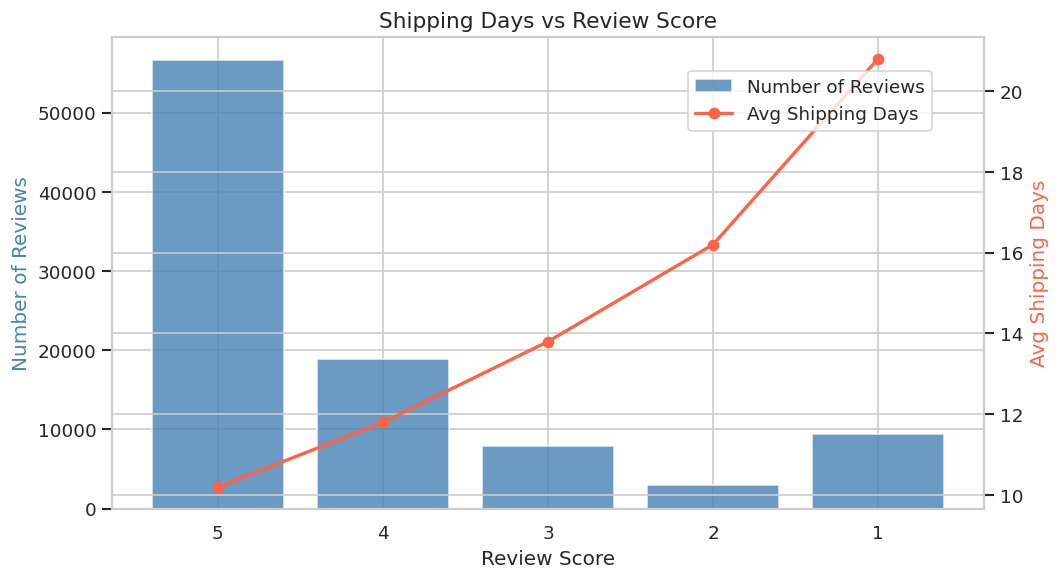

In [8]:
# Query 1 Visualization:
#dual-axis chart (bars = review count, line = shipping days)
fig, ax1 = plt.subplots(figsize=(9, 5))

# Sorting by review scores (5→1)
plot_df = review_vs_delivery.sort_values('review_score', ascending=False)

# Primary axis: number of reviews (bars)
ax1.bar(plot_df['review_score'].astype(str),
        plot_df['number_of_reviews'],
        color='steelblue', alpha=0.8, label='Number of Reviews')
ax1.set_xlabel('Review Score')
ax1.set_ylabel('Number of Reviews', color='steelblue')

# Secondary axis: avg shipping days (line)
ax2 = ax1.twinx()
ax2.plot(plot_df['review_score'].astype(str),
         plot_df['avg_shipping_days'],
         color='tomato', marker='o', linewidth=2, label='Avg Shipping Days')
ax2.set_ylabel('Avg Shipping Days', color='tomato')

ax1.set_title('Shipping Days vs Review Score', fontsize=13)
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

**SQL Finding 1:** Customers who give 5-star reviewers (satisfied) received their orders in 10.6 days on average, which is half the time of 1-star (unsatisfied) reviewers (21 days). Meeting the estimated delivery date is the single most impactful threshold: missing it drops the average score from **4.29 → 2.27**.

### Adding State & City Level Delivery Analysis

The previous two queries looked at delivery patterns across the whole dataset. Now we add geography to the equation to see where the delivery problems actually live.

In [9]:
# Query 3: Delivery Performance by State
# Extended version of Query 1: same delivery metrics grouped by customer state
# Shows which states have the slowest delivery and lowest satisfaction

q_state_delivery = """
--CTE 1: Same delivery time calculation as before, but added states
WITH delivery_time AS (
    SELECT
        o.order_id,
        c.customer_state,
        CAST(JULIANDAY(o.order_delivered_customer_date) - JULIANDAY(o.order_purchase_timestamp) AS INT) AS shipping_days,
        --positive = arrived early, negative = arrived late
        CAST(JULIANDAY(o.order_estimated_delivery_date) - JULIANDAY(o.order_delivered_customer_date) AS INT) AS days_ahead_of_estimate
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
),
--CTE 2: Same in-time/overdue classification, now with state attached
delivery_groups AS (
    SELECT
        d.order_id,
        d.customer_state,
        d.shipping_days,
        d.days_ahead_of_estimate,
        r.review_score,
        CASE
            WHEN d.days_ahead_of_estimate < 0 THEN 'overdue'
            ELSE 'in-time'
        END AS delivery_group
    FROM delivery_time d
    JOIN (SELECT order_id, MIN(review_score) AS review_score FROM order_reviews GROUP BY order_id) r
        ON d.order_id = r.order_id
)
--Aggregating by state
SELECT
    customer_state,
    COUNT(*) AS total_orders,
    ROUND(AVG(shipping_days), 1) AS avg_shipping_days,
    ROUND(AVG(days_ahead_of_estimate), 1) AS avg_days_ahead_of_estimate,
    ROUND(AVG(review_score), 2) AS avg_review_score,
    ROUND(SUM(CASE WHEN delivery_group = 'overdue' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS pct_overdue
FROM delivery_groups
GROUP BY customer_state
HAVING total_orders >= 100
ORDER BY avg_shipping_days ASC
"""

state_delivery = sql(q_state_delivery)
print(f"States with 100+ delivered orders: {len(state_delivery)}")
print(" ")
print("Delivery Breakdown by state:")
state_delivery

States with 100+ delivered orders: 24
 
Delivery Breakdown by state:


,customer_state,total_orders,avg_shipping_days,avg_days_ahead_of_estimate,avg_review_score,pct_overdue
0,SP,40266,8.3,10.2,4.24,4.4
1,MG,11285,11.5,12.3,4.19,4.5
2,PR,4900,11.5,12.4,4.24,4.0
3,DF,2070,12.5,11.1,4.13,5.7
4,SC,3519,14.4,10.7,4.13,8.1
5,RJ,12211,14.8,11.0,3.96,11.9
6,RS,5326,14.8,13.0,4.18,6.0
7,GO,1946,15.1,11.3,4.10,6.4
8,ES,1969,15.2,9.8,4.08,10.4
9,MS,699,15.2,10.1,4.16,9.7


In [10]:
# Query 4: In-Time vs Overdue by City
# Extended version of Query 2: same on-time/overdue classification, grouped by city
# Filtered to cities with 100+ orders to get statistically meaningful results

q_city_delivery = """
--Same two CTEs as Query 2
WITH delivery_time AS (
    SELECT
        o.order_id,
        c.customer_state,
        c.customer_city,
        CAST(JULIANDAY(o.order_delivered_customer_date) - JULIANDAY(o.order_purchase_timestamp) AS INT) AS shipping_days,
        CAST(JULIANDAY(o.order_estimated_delivery_date) - JULIANDAY(o.order_delivered_customer_date) AS INT) AS days_ahead_of_estimate
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
),
delivery_groups AS (
    SELECT
        d.order_id,
        d.customer_state,
        d.customer_city,
        d.shipping_days,
        d.days_ahead_of_estimate,
        r.review_score,
        CASE
            WHEN d.days_ahead_of_estimate < 0 THEN 'overdue'
            ELSE 'in-time'
        END AS delivery_group
    FROM delivery_time d
    JOIN (SELECT order_id, MIN(review_score) AS review_score FROM order_reviews GROUP BY order_id) r
        ON d.order_id = r.order_id
)
--Aggregating by city(in-time/overdue by city)
SELECT
    customer_state,
    customer_city,
    COUNT(*) AS total_orders,
    ROUND(AVG(shipping_days), 1) AS avg_shipping_days,
    ROUND(AVG(review_score), 2) AS avg_review_score,
    SUM(CASE WHEN delivery_group = 'in-time' THEN 1 ELSE 0 END) AS intime_orders,
    SUM(CASE WHEN delivery_group = 'overdue' THEN 1 ELSE 0 END) AS overdue_orders,
    ROUND(SUM(CASE WHEN delivery_group = 'overdue' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS pct_overdue,
    ROUND(SUM(CASE WHEN delivery_group = 'overdue' THEN 1.0 ELSE 0 END) OVER () * 100.0 / COUNT(*) OVER (), 1) AS avg_overdue
FROM delivery_groups
GROUP BY customer_state, customer_city
HAVING total_orders >= 100
ORDER BY pct_overdue ASC
"""

city_delivery = sql(q_city_delivery)
print(f"Cities with 100+ delivered orders: {len(city_delivery)}")
print(" ")
print("Top 15 cities with lowest overdue rate (best logistics):")
city_delivery.head(15)

Cities with 100+ delivered orders: 134
 
Top 15 cities with lowest overdue rate (best logistics):


,customer_state,customer_city,total_orders,avg_shipping_days,avg_review_score,intime_orders,overdue_orders,pct_overdue,avg_overdue
0,SP,aracatuba,137,9.7,4.18,136,1,0.7,3.7
1,MG,divinopolis,132,10.7,4.23,131,1,0.8,3.7
2,RS,gravatai,111,13.8,4.20,110,1,0.9,3.7
3,SP,franco da rocha,106,6.8,4.18,105,1,0.9,3.7
4,SP,braganca paulista,142,6.9,4.30,140,2,1.4,3.7
5,SP,sao caetano do sul,271,7.6,4.30,266,5,1.8,3.7
6,SP,taubate,258,9.6,4.18,253,5,1.9,3.7
7,SP,piracicaba,356,7.3,4.26,349,7,2.0,3.7
8,SP,sorocaba,605,7.4,4.34,593,12,2.0,3.7
9,SP,cotia,241,6.7,4.23,236,5,2.1,3.7


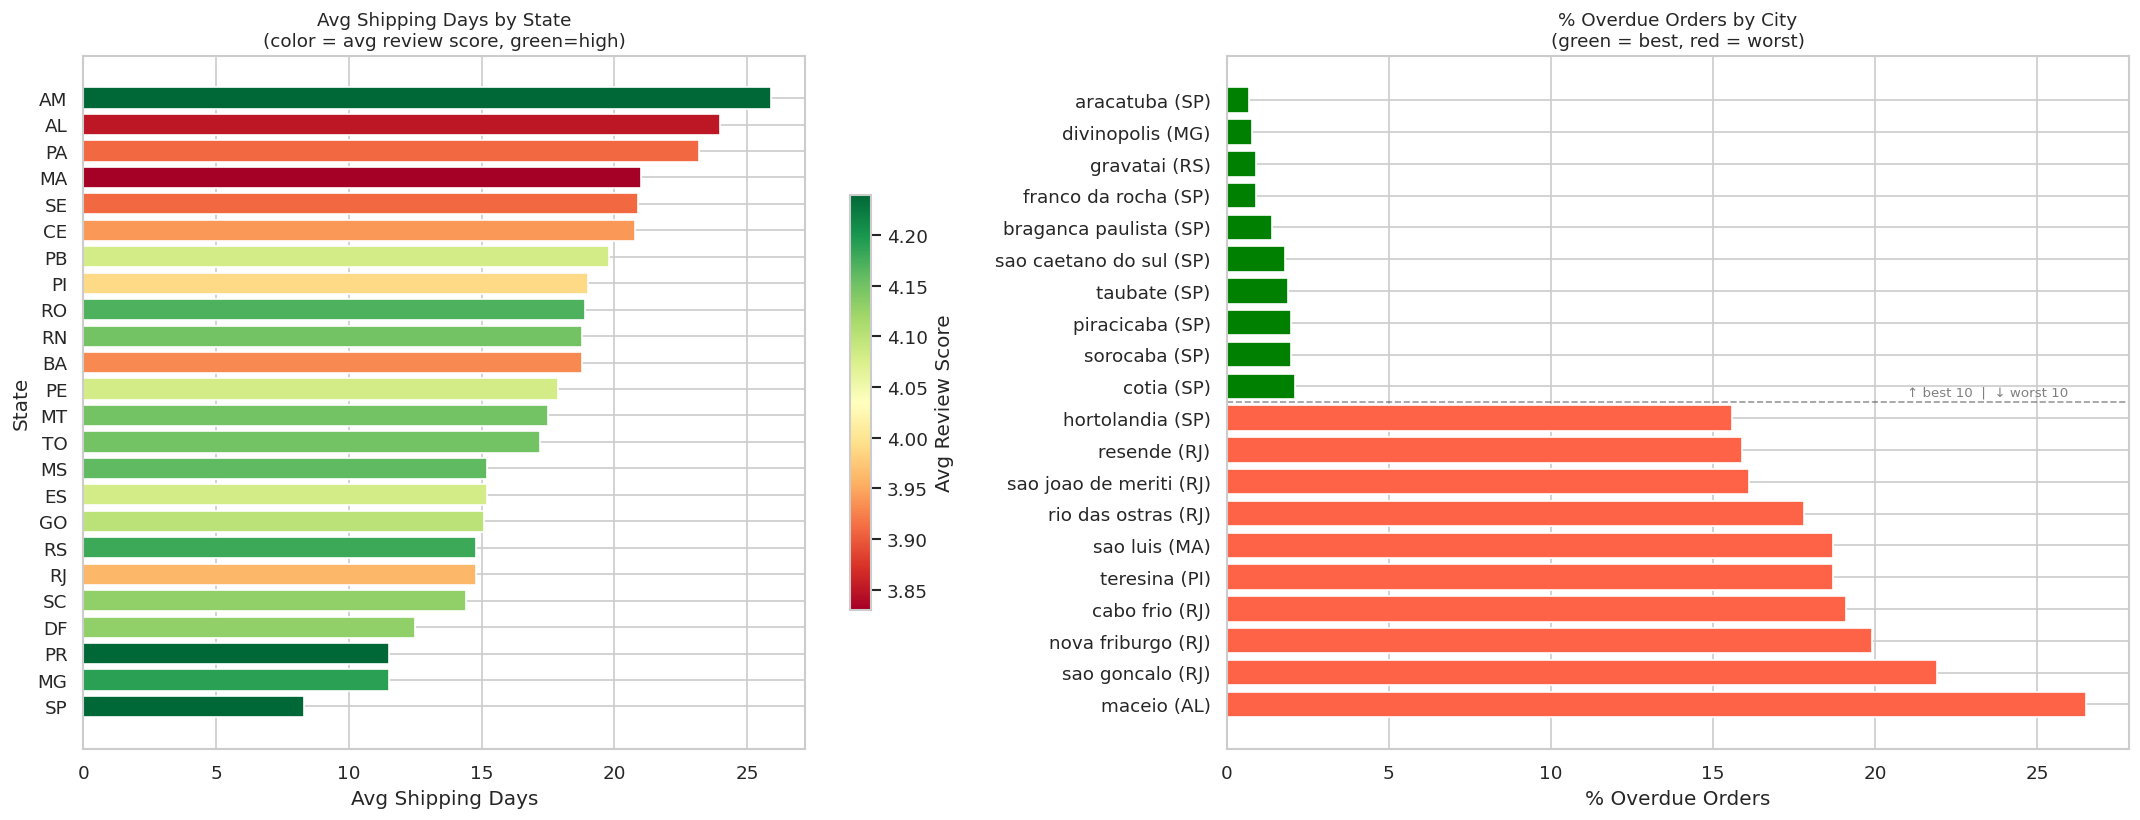

In [11]:
# Visualization of both charts side by side:
# Left: state-level AVG shipping days (slowest to fastest)
# Right: best/worst 10 cities by overdue rate

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left chart: Avg shipping days by state
states_sorted = state_delivery.sort_values('avg_shipping_days', ascending=True)

# Colors (show satisfaction): red = low score, green = high score
norm = plt.Normalize(states_sorted['avg_review_score'].min(),
                     states_sorted['avg_review_score'].max())
colors = plt.cm.RdYlGn(norm(states_sorted['avg_review_score']))

ax1.barh(states_sorted['customer_state'], states_sorted['avg_shipping_days'],
         color=colors, edgecolor='white')
ax1.set_title('Avg Shipping Days by State\n(color = avg review score, green=high)', fontsize=11)
ax1.set_xlabel('Avg Shipping Days')
ax1.set_ylabel('State')

sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=norm)
plt.colorbar(sm, ax=ax1, label='Avg Review Score', shrink=0.6)


# Right chart: Top/bottom 10 cities by overdue rate

best_cities  = city_delivery.head(10).copy()
worst_cities = city_delivery.tail(10).copy()
cities_plot  = pd.concat([best_cities, worst_cities])
city_labels  = cities_plot['customer_city'] + ' (' + cities_plot['customer_state'] + ')'

bar_colors = ['green'] * 10 + ['tomato'] * 10
ax2.barh(city_labels, cities_plot['pct_overdue'], color = bar_colors, edgecolor='white')
ax2.axhline(y=9.5, color='black', linewidth=1, linestyle='--', alpha=0.4)
ax2.text(cities_plot['pct_overdue'].max() * 0.98, 9.3,
         '↑ best 10  |  ↓ worst 10', ha='right', fontsize=8, color='grey')
ax2.set_title('% Overdue Orders by City\n(green = best, red = worst)', fontsize=11)
ax2.set_xlabel('% Overdue Orders')

ax2.invert_yaxis()

plt.tight_layout()
plt.show()

**SQL Findings 2 :** Delivery speed varies significantly by state. Northern/remote states tend to have both longer shipping times and higher overdue rates, which directly decreases the average review scores — exactly the pattern we saw at the order level in Queries 1 and 2.

---
## 3. Python: Retention by Cohort Analysis

**Cohort - First purchase month**.

**Cohort Index - Months since first purchase**

In [12]:
# Setup
# Filtering for only delivered orders
delivered_orders = orders[orders['order_status'] == 'delivered']

# Joining orders info with customer info
first_join = pd.merge(
    delivered_orders[['order_id', 'customer_id', 'order_purchase_timestamp']],
    customers[['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']],
    on = 'customer_id',
    how = 'left'
)

# Filtering order payments to be 1 per order_id
payment = order_payments.groupby('order_id')['payment_value'].sum().reset_index()

# Adding payment info
second_join = pd.merge(
    first_join,
    payment,
    on = 'order_id',
    how = 'left'
)

# Made a copy called df for easier analysis
df = second_join.copy()

# Parse the date and create a 'month' column (used for cohorts)
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp']).dt.normalize()
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

print(f"Delivered orders : {len(df): }")
print(f"Unique customers : {df['customer_unique_id'].nunique(): }")
df.head(3)

Delivered orders :  96478
Unique customers :  93358


,order_id,customer_id,order_purchase_timestamp,customer_unique_id,customer_state,customer_city,payment_value,month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,38.71,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24,af07308b275d755c9edb36a90c618231,BA,barreiras,141.46,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,179.12,2018-08


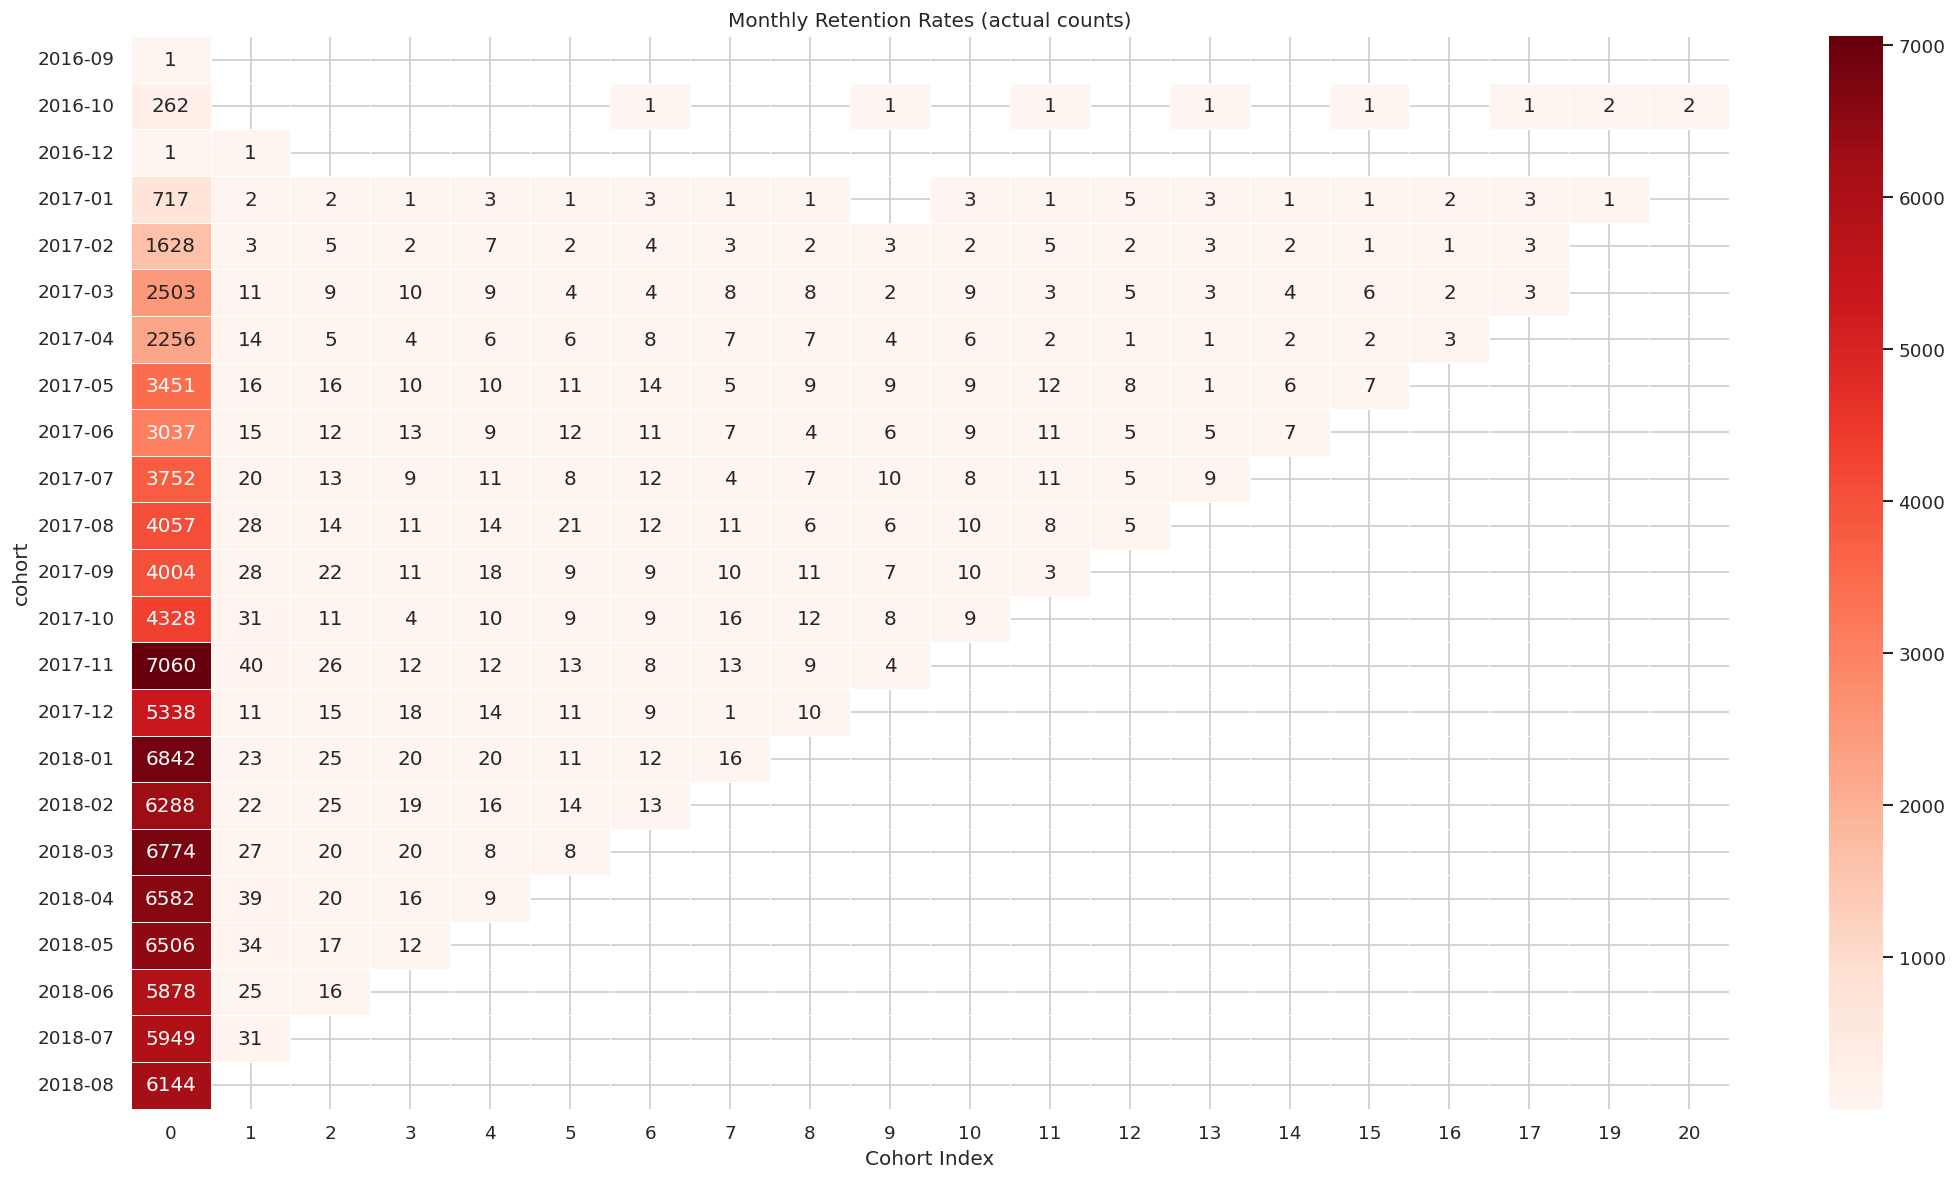

In [13]:
# Cohort Retention Analysis

#Assigning customers to their cohorts (first purchase month)
df['cohort'] = df.groupby('customer_unique_id')['month'].transform('min')


#Creating cohort index (months difference)
month = df['month'].dt.month
year = df['month'].dt.year
cohort_month = df['cohort'].dt.month
cohort_year = df['cohort'].dt.year

year_diff = year - cohort_year
month_diff = month - cohort_month

df['Cohort Index'] = year_diff*12 + month_diff


#Calculating the number of unique users per cohort
cohort_data = df.groupby(['cohort', 'Cohort Index'])['customer_unique_id'].nunique().reset_index()


#Creating pivot table for visualization
cohort_table = cohort_data.pivot(
    index = 'cohort',
    columns = 'Cohort Index',
    values = 'customer_unique_id'
)




#Plot 1: Retention in actual numbers:

plt.figure(figsize=(18, 10))
plt.title('Monthly Retention Rates (actual counts)')
sns.heatmap(
    cohort_table,
    annot = True,
    fmt = '.0f',
    cmap = 'Reds',
    linewidth = 0.3
)
plt.tight_layout()
plt.show()

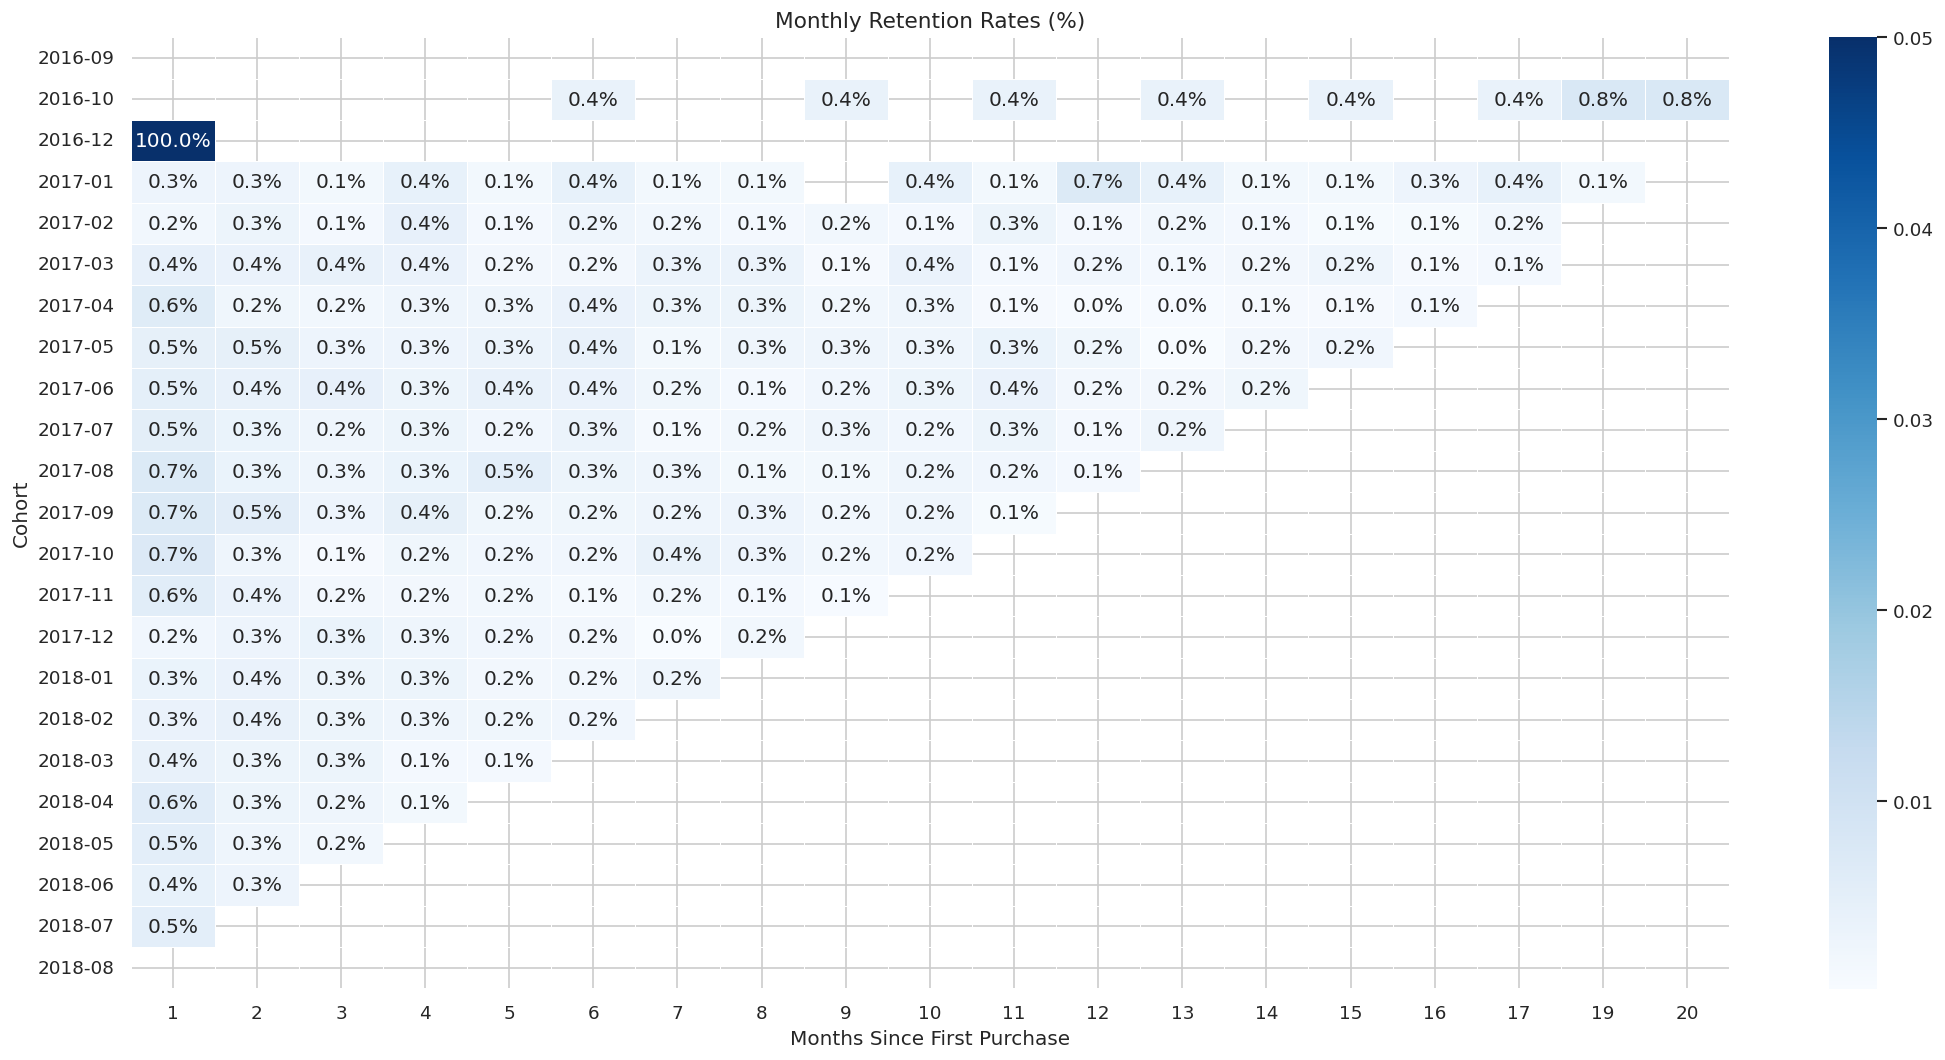

In [14]:
# Calculating Retention rates (%)

cohort_size = cohort_table[0]
retention = cohort_table.divide(cohort_size, axis=0)

# Plot 2: Retention Rates in Percentages
plt.figure(figsize=(18, 9))
plt.title('Monthly Retention Rates (%)', fontsize=13)
sns.heatmap(
    retention.iloc[:, 1:],
    annot=True,
    fmt='.1%',
    cmap='Blues',
    vmax=0.05,
    linewidth=0.3
)
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort')
plt.tight_layout()
plt.show()

---
## 4. Python — Customer Lifetime Value (Global & by Cohort)

###Formula:
**CLV** = Average Order Value × Purchase Frequency (per year) × Customer Lifespan (years)

In [15]:
# Global CLV (for this dataset)

aov = df['payment_value'].mean()

total_orders = df['order_id'].nunique()
total_customers = df['customer_unique_id'].nunique()
dataset_days = (df['order_purchase_timestamp'].max() - df['order_purchase_timestamp'].min()).days

# Purchase frequency = orders per customer per year
purchase_freq_year = (total_orders / total_customers) * (365 / dataset_days)

# Lifespan: estimated as 1 year
avg_lifespan = 1.0

clv = round(aov * purchase_freq_year * avg_lifespan, 2)

print(f"{'Average Order Value':<40} : {aov:.2f} BRL")
print(f"{'Average Purchase Frequency per Year':<40} : {purchase_freq_year:.2f}")
print(f"{'Average Customer lifespan':<40} : {avg_lifespan:.2f} years")
print(" ")
print(f"{'Global Customer Lifetime Value estimate':<40} : {clv:.2f} BRL")

Average Order Value                      : 159.86 BRL
Average Purchase Frequency per Year      : 0.53
Average Customer lifespan                : 1.00 years
 
Global Customer Lifetime Value estimate  : 84.57 BRL


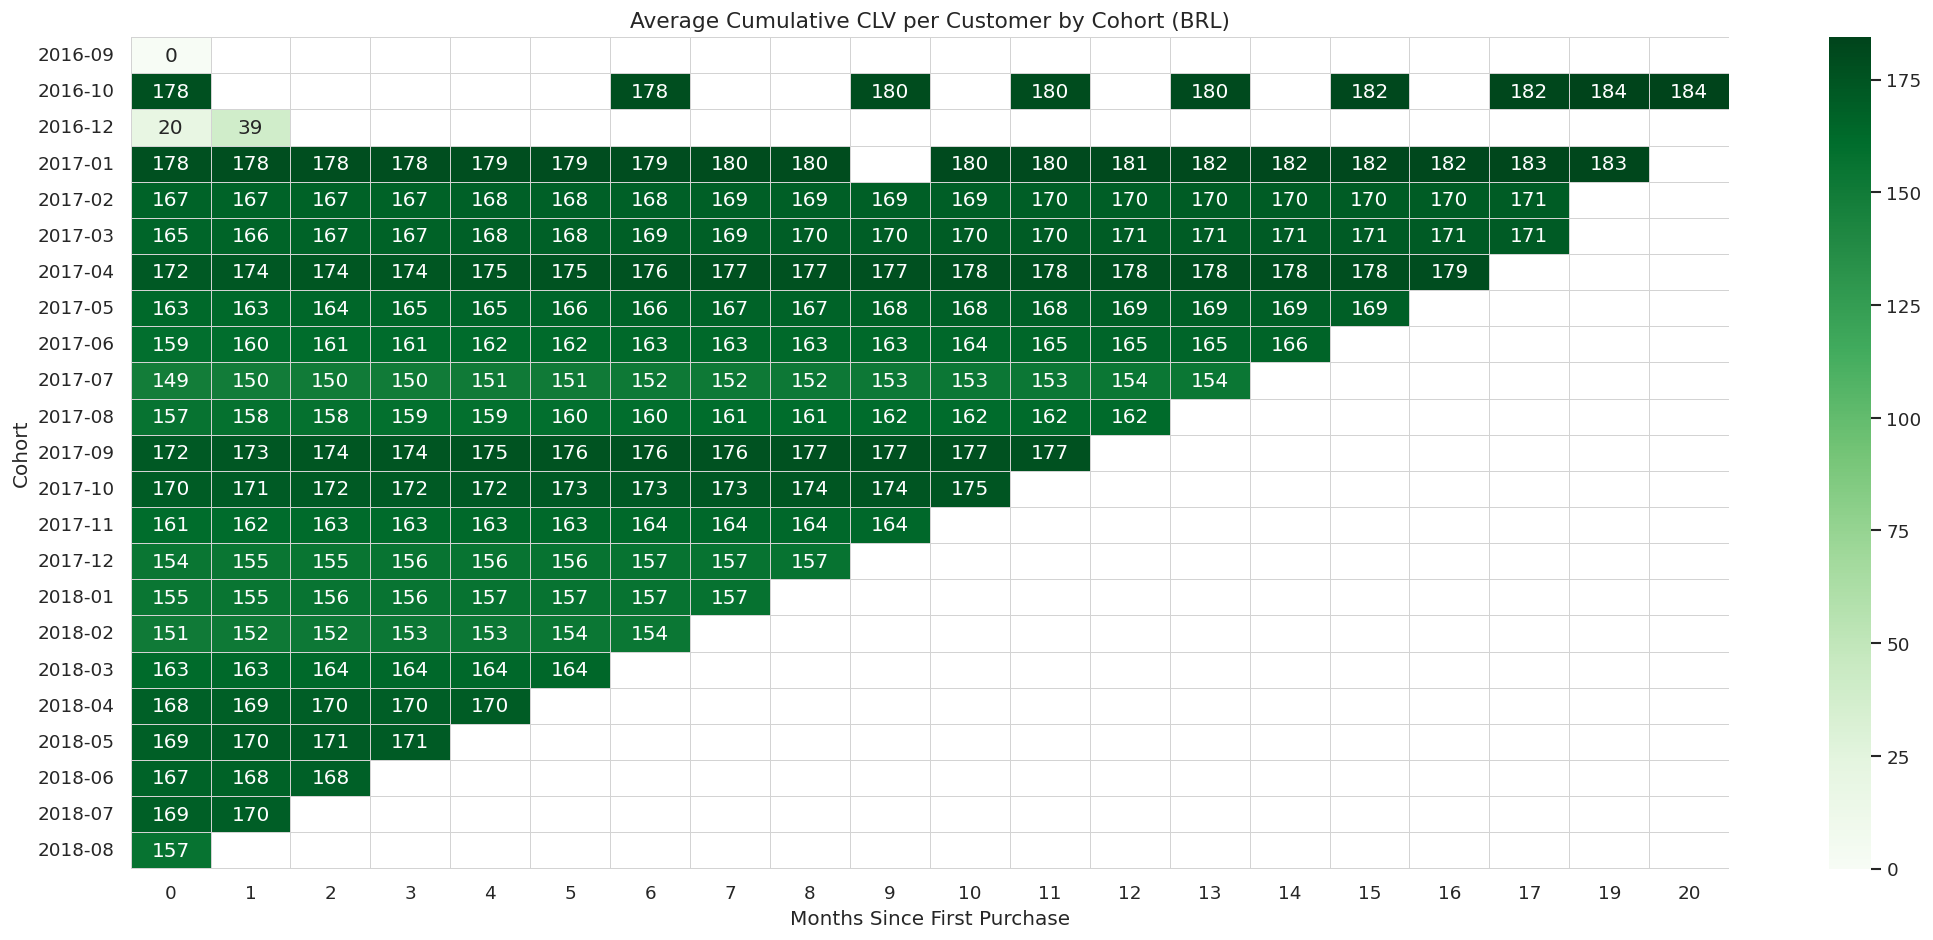

In [16]:
# Cumulative CLV by Cohort

clv_cohort_data = df.groupby(['cohort', 'Cohort Index'])['payment_value'].sum().reset_index()
clv_cohort_table = clv_cohort_data.pivot(
    index='cohort', columns='Cohort Index', values='payment_value'
)

clv_cumulative = clv_cohort_table.cumsum(axis=1)

cohort_size_for_clv = df.groupby(df['cohort'].astype(str))['customer_unique_id'].nunique()
clv_cumulative.index = clv_cumulative.index.astype(str)
clv_per_customer = clv_cumulative.divide(cohort_size_for_clv, axis=0)

# Heatmap: each cell represents average cumulative revenue per customer by that month
plt.figure(figsize=(18, 8))
plt.grid(False)
plt.title('Average Cumulative CLV per Customer by Cohort (BRL)', fontsize=13)
sns.heatmap(
    clv_per_customer,
    annot=True,
    fmt='.0f',
    cmap='Greens',
    linewidths=0.5,
    linecolor='lightgrey'
)

plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort')
plt.tight_layout()
plt.show()

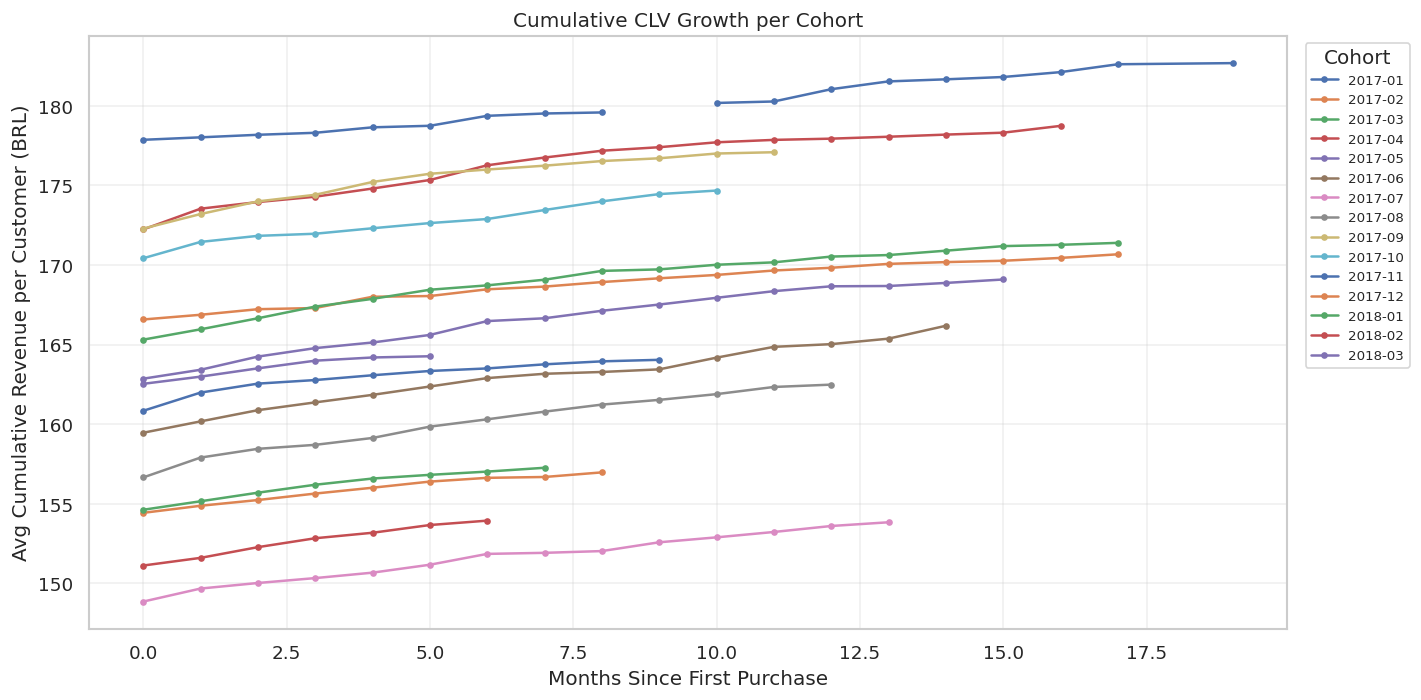

In [17]:
# CLV growth curves
# Each line = one cohort
# Filtered for cohorts with minimum 6 months of data and no Nan for meaningful visuals

clv_lines = clv_per_customer.dropna(subset=[5])

clv_lines.T.plot(figsize=(12, 6), marker='o', markersize=3)
plt.title('Cumulative CLV Growth per Cohort')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Avg Cumulative Revenue per Customer (BRL)')
plt.grid(True, alpha=0.3)
plt.legend(title='Cohort', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

---
## 5. Python: State-Level Analysis: AOV, CLV, Retention

Extending previous ananlysis with the **State** data

In [18]:
# Building df with 1 row per customer

cust_agg = (
    df.groupby(['customer_unique_id', 'customer_state']).agg(
        total_orders = ('order_id', 'nunique'),
        total_revenue = ('payment_value', 'sum'),
        first_purchase = ('order_purchase_timestamp', 'min'),
        last_purchase = ('order_purchase_timestamp', 'max'),
    ).reset_index()
)

# Repeat customer
cust_agg['is_repeat'] = cust_agg['total_orders'] > 1

# Lifetime for each customer
cust_agg['lifetime_days'] = (cust_agg['last_purchase'] - cust_agg['first_purchase']).dt.days + 1

# AOV per customer = their total spend / number of orders
cust_agg['aov']  = cust_agg['total_revenue'] / cust_agg['total_orders']

print(f"Unique customers: {len(cust_agg)}")
cust_agg.head(3)

Unique customers: 93396


,customer_unique_id,customer_state,total_orders,total_revenue,first_purchase,last_purchase,is_repeat,lifetime_days,aov
0,0000366f3b9a7992bf8c76cfdf3221e2,SP,1,141.90,2018-05-10,2018-05-10,False,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,1,27.19,2018-05-07,2018-05-07,False,1,27.19
2,0000f46a3911fa3c0805444483337064,SC,1,86.22,2017-03-10,2017-03-10,False,1,86.22


In [19]:
# Adding state to the equation

state_summary = (
    cust_agg.groupby('customer_state').agg(
        unique_customers = ('customer_unique_id', 'nunique'),
        repeat_customers = ('is_repeat', 'sum'),
        total_revenue = ('total_revenue', 'sum'),
        avg_aov = ('aov', 'mean'),
        avg_clv = ('total_revenue', 'mean'),
        avg_lifetime_days = ('lifetime_days', 'mean'),
    ).reset_index()
)

# Retention = number of repeat customers / number of all customers
state_summary['retention_rate'] = (
    state_summary['repeat_customers'] / state_summary['unique_customers'] * 100
).round(2)

# Filter to states with 200+ customers for reliable statistics
state_summary = state_summary[state_summary['unique_customers'] >= 200].round(2)

print(f"States with 200+ customers: {len(state_summary)}")
state_summary.sort_values('avg_clv', ascending=False)

States with 200+ customers: 23


,customer_state,unique_customers,repeat_customers,total_revenue,avg_aov,avg_clv,avg_lifetime_days,retention_rate
14,PB,504,10,137834.65,268.43,273.48,2.03,1.98
20,RO,231,9,56975.70,238.83,246.65,6.18,3.90
1,AL,387,10,94195.79,235.74,243.40,2.59,2.58
13,PA,922,22,212027.55,226.20,229.96,2.87,2.39
16,PI,464,10,105272.17,221.96,226.88,2.46,2.16
26,TO,267,7,60007.37,220.27,224.75,3.98,2.62
19,RN,464,10,100728.30,213.42,217.09,2.67,2.16
24,SE,329,6,70289.13,209.09,213.64,2.68,1.82
12,MT,856,28,181441.72,207.14,211.96,3.02,3.27
5,CE,1258,20,266463.97,209.36,211.82,2.08,1.59


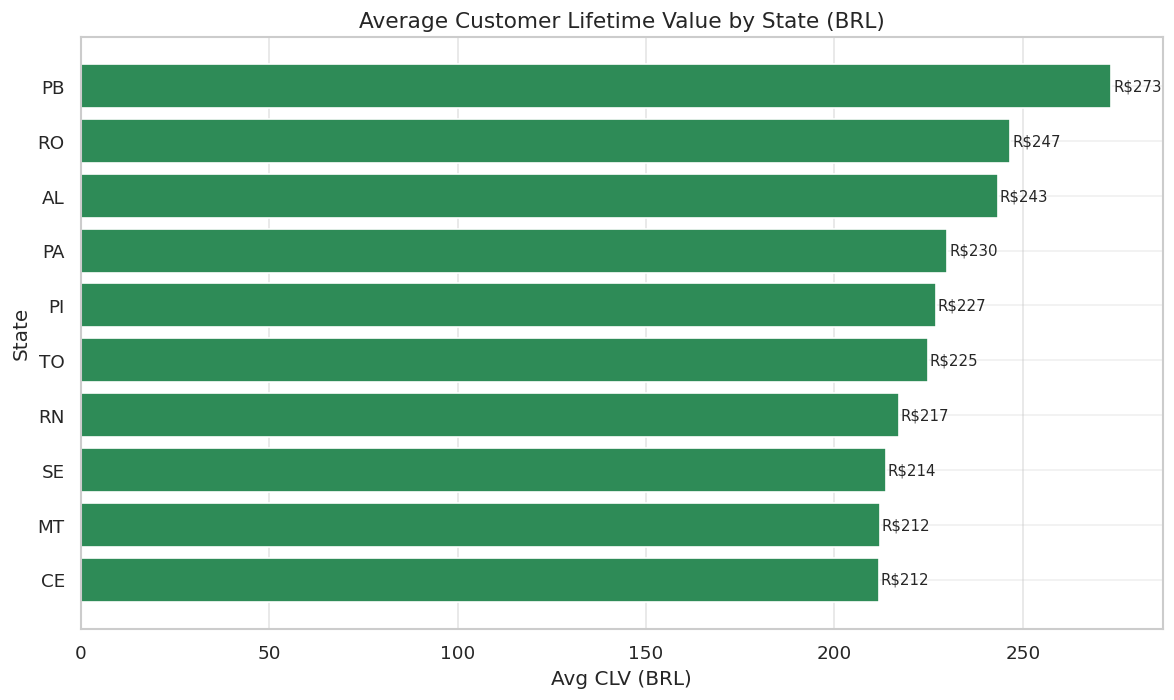

In [20]:
# Visuals
# Plot 1: Top states by average CLV

top_clv = state_summary.sort_values('avg_clv', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_clv['customer_state'],
               top_clv['avg_clv'],
               color='seagreen',
               edgecolor='white')

ax.set_title('Average Customer Lifetime Value by State (BRL)', fontsize=13)
ax.set_xlabel('Avg CLV (BRL)')
ax.set_ylabel('State')
ax.grid(axis='y', alpha=0.3)
ax.grid(axis='x', alpha=0.5)

# Adding labels
for bar, val in zip(bars, top_clv['avg_clv']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'R${val:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 6. Connecting SQL (Delivery/Satisfaction) Findings to Python Retention

**Hypothesis:**
> States with faster, more reliable delivery → higher review scores → more repeat customers

In [21]:
# Merging SQL delivery metrics with Python retention metrics to find patterns
# state_delivery comes from Query 3 (SQL section)
# state_summary comes from Section 5 (Python section)
# Inner join to only keep states that appear in both tables

bridge = state_delivery.merge(
    state_summary[['customer_state', 'retention_rate', 'avg_aov', 'avg_clv', 'unique_customers']],
    on='customer_state',
    how='inner'
)

print(f"States in bridge table: {len(bridge)}")
bridge.sort_values('avg_review_score', ascending=False)

States in bridge table: 23


,customer_state,total_orders,avg_shipping_days,avg_days_ahead_of_estimate,avg_review_score,pct_overdue,retention_rate,avg_aov,avg_clv,unique_customers
0,SP,40266,8.3,10.2,4.24,4.4,3.10,142.76,147.37,39156
2,PR,4900,11.5,12.4,4.24,4.0,2.89,159.47,163.96,4769
1,MG,11285,11.5,12.3,4.19,4.5,2.89,160.72,165.37,11001
6,RS,5326,14.8,13.0,4.18,6.0,3.04,161.19,166.76,5168
15,RO,242,18.9,19.1,4.17,2.9,3.90,238.83,246.65,231
9,MS,699,15.2,10.1,4.16,9.7,2.50,193.59,197.39,681
14,RN,471,18.8,12.8,4.15,9.1,2.16,213.42,217.09,464
11,MT,879,17.5,13.5,4.15,5.8,3.27,207.14,211.96,856
10,TO,273,17.2,11.2,4.15,9.9,2.62,220.27,224.75,267
3,DF,2070,12.5,11.1,4.13,5.7,2.87,167.67,171.44,2019


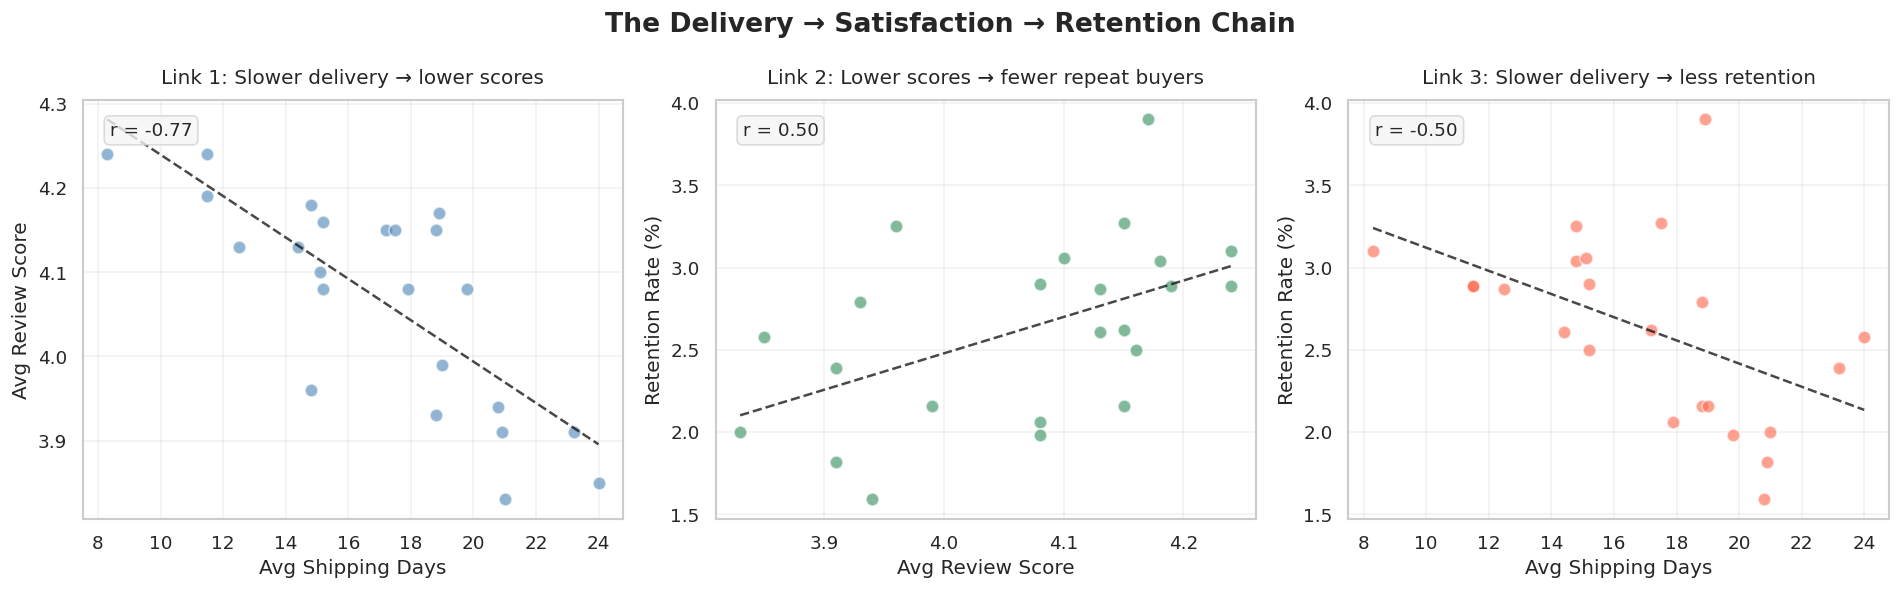

In [22]:
# Visuals
# Plot 1: Chain Scatter plot
# Plot structure:
#                 Link 1: Slower delivery = lower customer satisfaction
#                 Link 2: Lower custmomer satisfaction = less repeat purchases
#                 Link 3: Slower delivery = less repeat purchases

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('The Delivery → Satisfaction → Retention Chain', fontsize=16, fontweight='bold')

chart_text = [
    {
        'x_column': 'avg_shipping_days',
        'y_column': 'avg_review_score',
        'x_label': 'Avg Shipping Days',
        'y_label': 'Avg Review Score',
        'color': 'steelblue',
        'title': 'Link 1: Slower delivery → lower scores'
    },
    {
        'x_column': 'avg_review_score',
        'y_column': 'retention_rate',
        'x_label': 'Avg Review Score',
        'y_label': 'Retention Rate (%)',
        'color': 'seagreen',
        'title': 'Link 2: Lower scores → fewer repeat buyers'
    },
    {
        'x_column': 'avg_shipping_days',
        'y_column': 'retention_rate',
        'x_label': 'Avg Shipping Days',
        'y_label': 'Retention Rate (%)',
        'color': 'tomato',
        'title': 'Link 3: Slower delivery → less retention'
    }
]

for i in range(3):
    ax = axes[i]
    text = chart_text[i]


    x_data = bridge[text['x_column']]
    y_data = bridge[text['y_column']]

    # Plotting raw observations
    ax.scatter(x_data, y_data, color=text['color'], s=60, alpha=0.6, edgecolor='white')

    # Simple linear regression line
    line_math = np.polyfit(x_data, y_data, 1)
    line_function = np.poly1d(line_math)
    x_line_points = np.linspace(x_data.min(), x_data.max(), 100)

    ax.plot(x_line_points, line_function(x_line_points), 'k--', linewidth=1.5, alpha=0.8)

    # Pearson correlation coefficient
    correlation_score = bridge[[text['x_column'], text['y_column']]].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f'r = {correlation_score:.2f}', transform=ax.transAxes, fontsize=11,
            va='top', bbox=dict(boxstyle='round', facecolor='whitesmoke', edgecolor='lightgrey', alpha=0.8))

    ax.set_title(text['title'], fontsize=12, pad=10)
    ax.set_xlabel(text['x_label'])
    ax.set_ylabel(text['y_label'])
    ax.grid(color='grey', linestyle='-', linewidth=0.2, alpha=0.5)

plt.tight_layout()
plt.show()

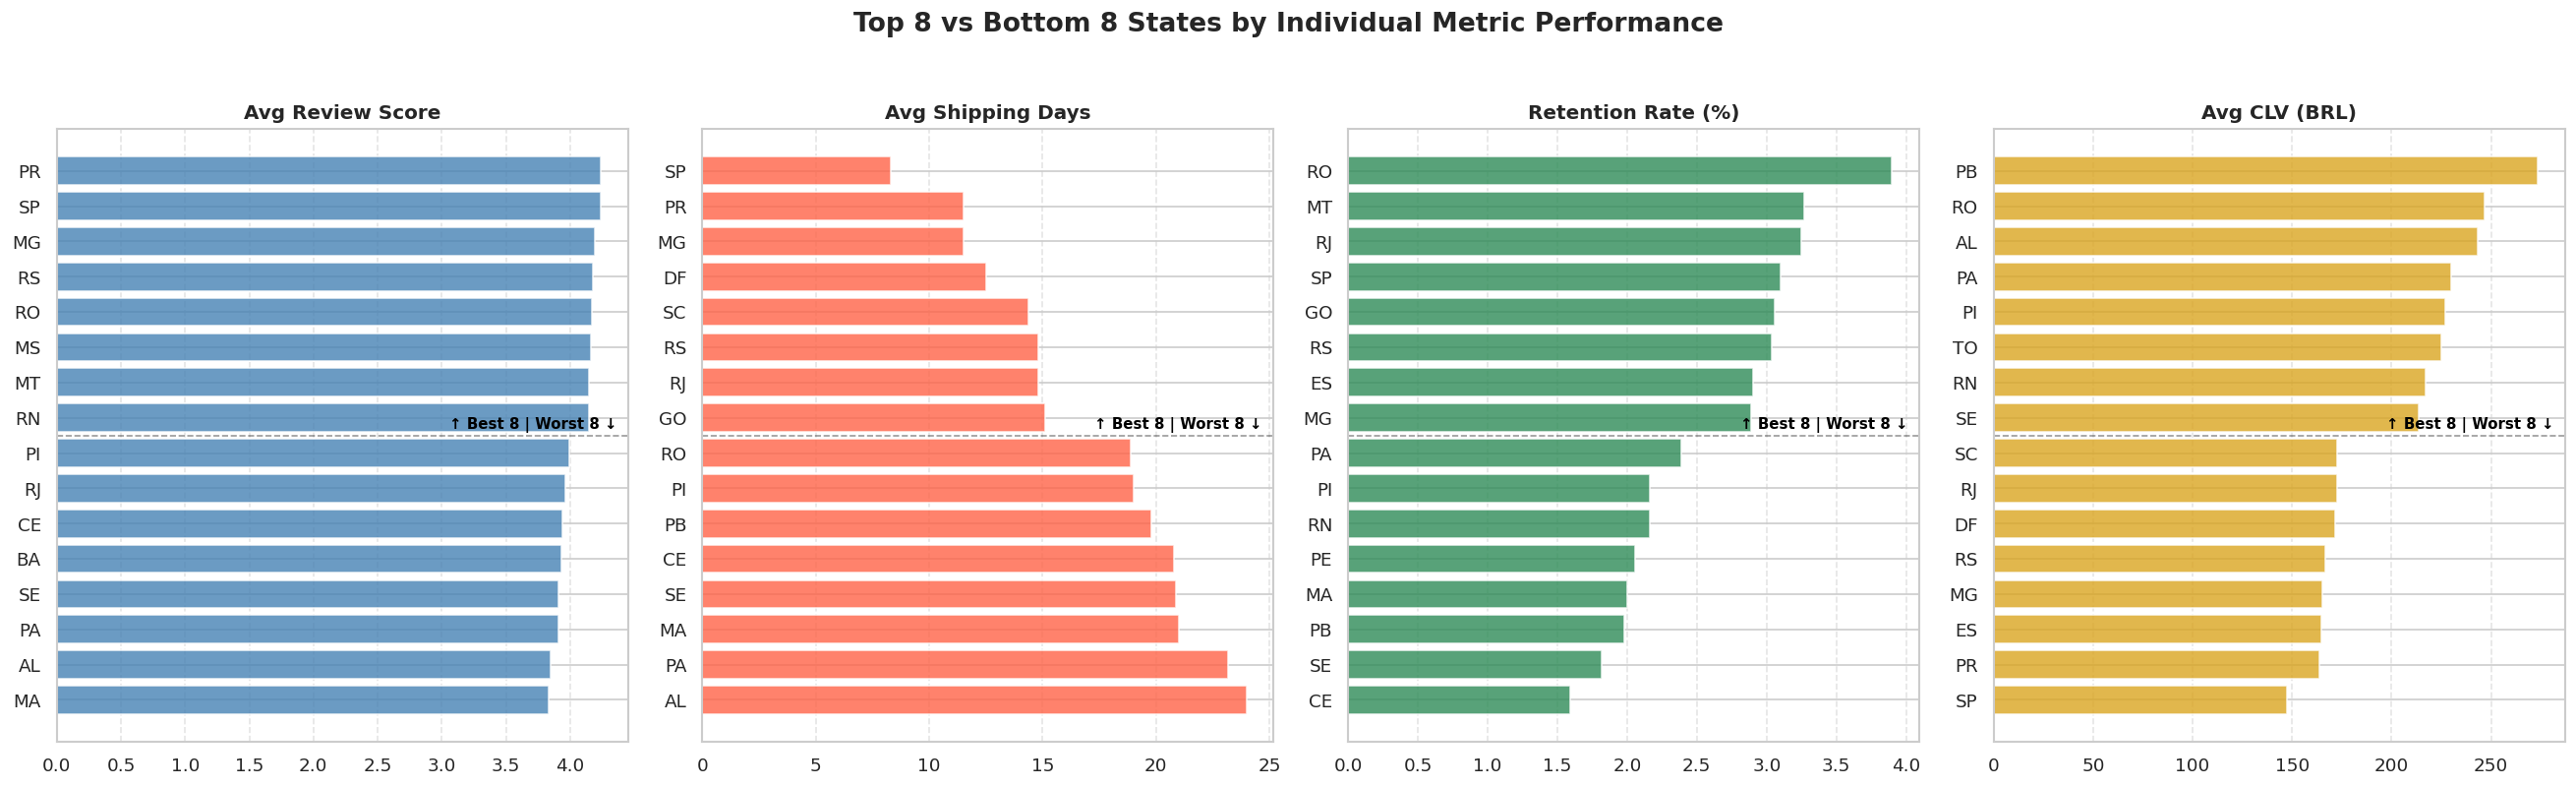

In [23]:
# Plot 2: Best & Worst states across all four key metrics (Review Score, Shipping Time, Retention (%), CLV)

# Seting up 4 places for plots
fig, axes = plt.subplots(1, 4, figsize=(22, 7))
fig.suptitle('Top 8 vs Bottom 8 States by Individual Metric Performance', fontsize=16, fontweight='bold')

# Metrics/sorting for each chart
metrics = [
    ('avg_review_score', 'Avg Review Score', 'steelblue', False),
    ('avg_shipping_days', 'Avg Shipping Days', 'tomato', True),
    ('retention_rate', 'Retention Rate (%)', 'seagreen', False),
    ('avg_clv', 'Avg CLV (BRL)', 'goldenrod', False)
]

for ax, (col, title, color, low_is_better) in zip(axes, metrics):

    # Sorting the data
    top_8 = bridge.sort_values(col, ascending=low_is_better).head(8)
    bottom_8 = bridge.sort_values(col, ascending=not low_is_better).head(8)

    plot_data = pd.concat([bottom_8.sort_values(col, ascending=not low_is_better),
                       top_8.sort_values(col, ascending=not low_is_better)])

    # Building the chart
    ax.barh(plot_data['customer_state'], plot_data[col],
            color=color, edgecolor='white', alpha=0.8)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

    ax.axhline(y=7.5, color='black', linewidth=1, linestyle='--', alpha=0.4)

    ax.text(ax.get_xlim()[1] * 0.98, 7.7, '↑ Best 8 | Worst 8 ↓',
            ha='right', fontsize=9, fontweight='bold', color='black')


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

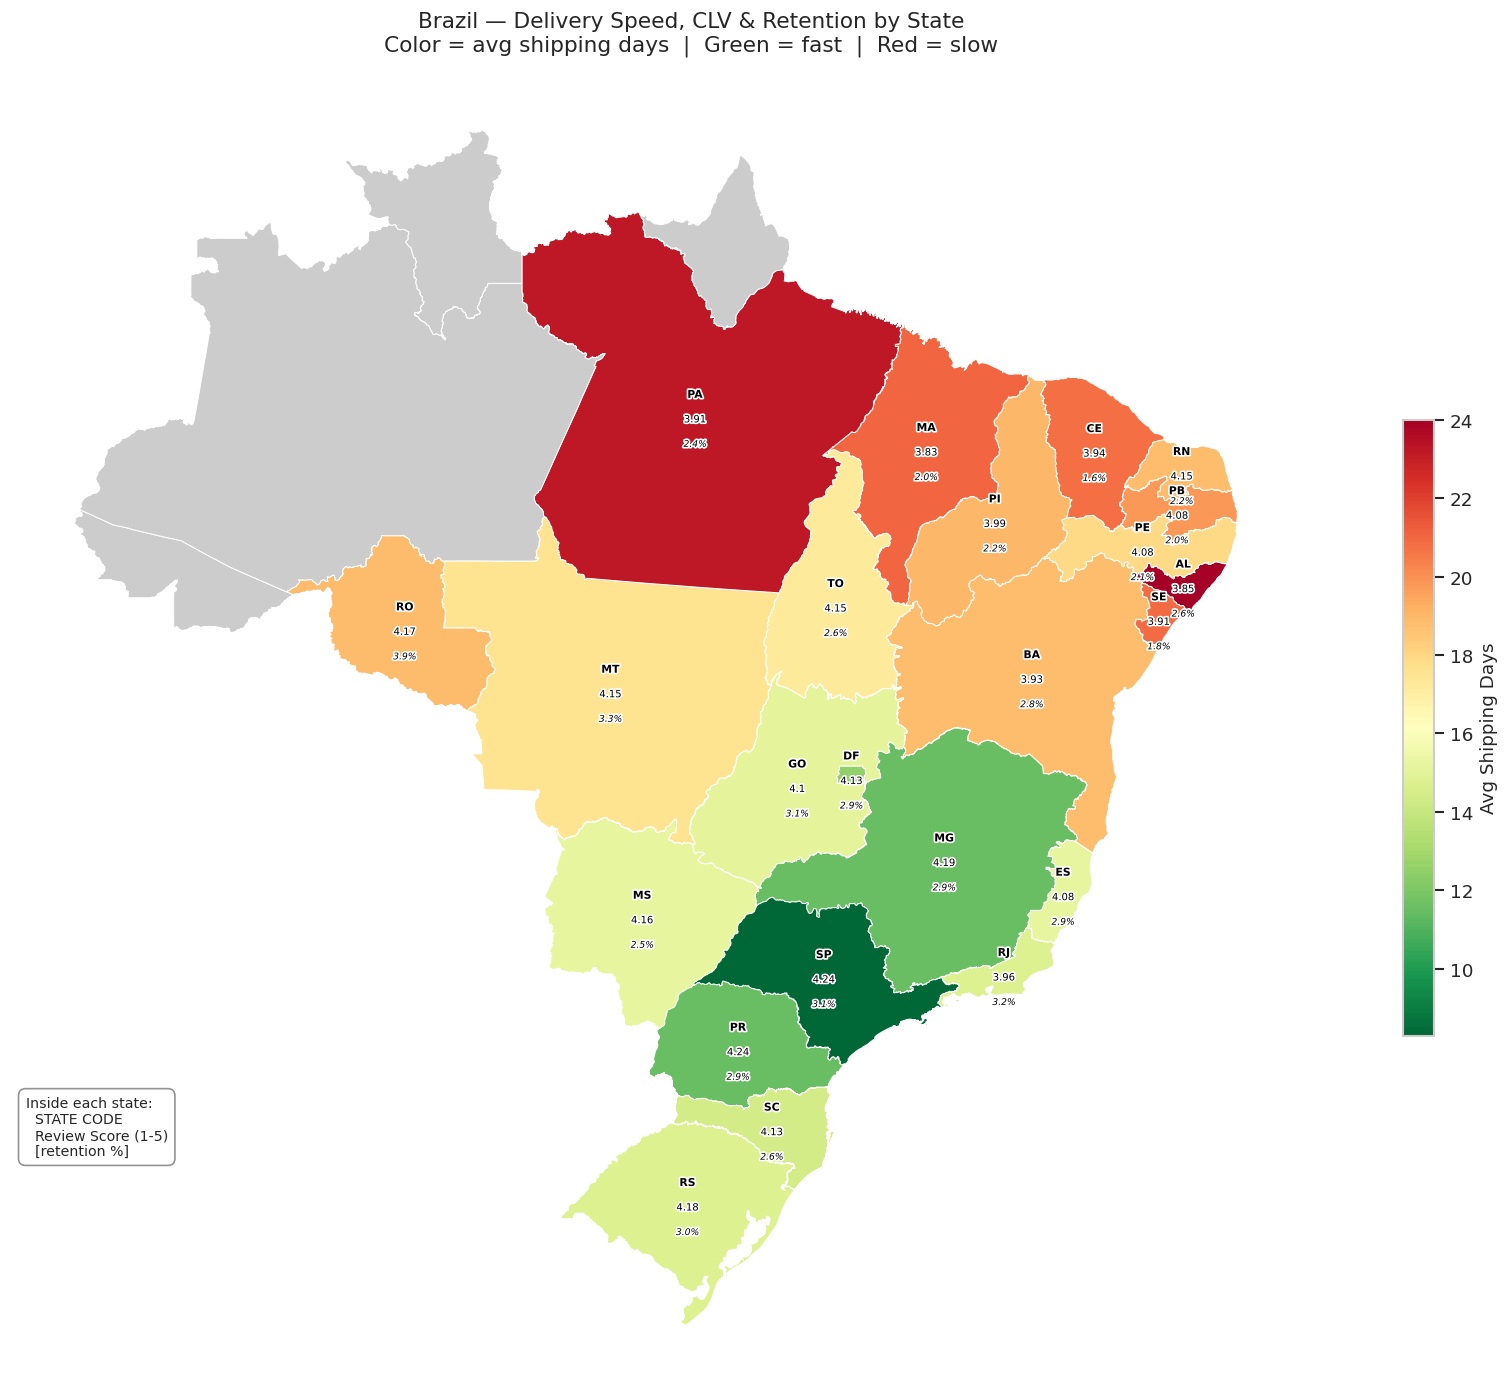

In [24]:
# ! Only included states with 200+ orders for statistically meaningful results
# Brazil state data
brazil = gpd.read_file(
    "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/brazil-states.geojson"
)

# Merging on states(column state is sigla in the file)
brazil = brazil.merge(
    bridge[['customer_state', 'avg_shipping_days', 'avg_review_score', 'retention_rate']],
    left_on='sigla',
    right_on='customer_state',
    how='left'
)

# Creating the map
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_facecolor('#d6eaf8')
ax.axis('off')

brazil.plot(
    ax=ax,
    column='avg_shipping_days',
    cmap='RdYlGn_r',
    edgecolor='white',
    linewidth=0.6,
    missing_kwds={'color': '#cccccc'}
)

norm = mcolors.Normalize(vmin=brazil['avg_shipping_days'].min(),
                          vmax=brazil['avg_shipping_days'].max())
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
cbar = plt.colorbar(sm, ax=ax, shrink=0.45, pad=0.02)
cbar.set_label('Avg Shipping Days', fontsize=11)

for _, row in brazil.iterrows():
    if pd.isna(row['avg_review_score']):
        continue

    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    outline = [pe.withStroke(linewidth=2, foreground='white')]

    ax.text(cx, cy + 0.5, row['sigla'],
            ha='center', fontsize=6.5, fontweight='bold',
            color='black', path_effects=outline)
    ax.text(cx, cy - 0.3, f"{row['avg_review_score']}",
            ha='center', fontsize=6,
            color='black', path_effects=outline)
    ax.text(cx, cy - 1.1, f"{row['retention_rate']:.1f}%",
            ha='center', fontsize=5.5, fontstyle='italic',
            color='black', path_effects=outline)

ax.text(0.01, 0.22, "Inside each state:\n  STATE CODE\n  Review Score (1-5)\n  [retention %]",
        transform=ax.transAxes, fontsize=8.5, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='grey'))

ax.set_title(
    'Brazil — Delivery Speed, CLV & Retention by State\n'
    'Color = avg shipping days  |  Green = fast  |  Red = slow',
    fontsize=13, pad=12
)

plt.tight_layout()
plt.show()

---
## 7. Key Takeaways

In [30]:
# All numbers come from variables calculated earlier in the notebook


# Retetnion
total_custs = df['customer_unique_id'].nunique()
repeat_custs = cust_agg['is_repeat'].sum()
global_aov = df['payment_value'].mean()

# Delivery/Satisfaction
intime_score  = ontime_vs_overdue.loc[ontime_vs_overdue['delivery_group'] == 'in-time',  'avg_review_score'].values[0]
overdue_score = ontime_vs_overdue.loc[ontime_vs_overdue['delivery_group'] == 'overdue', 'avg_review_score'].values[0]

# State-level correlations from the bridge table
r_ship_review = bridge[['avg_shipping_days', 'avg_review_score']].corr().iloc[0, 1]
r_review_ret  = bridge[['avg_review_score',  'retention_rate']].corr().iloc[0, 1]
r_ship_ret    = bridge[['avg_shipping_days',  'retention_rate']].corr().iloc[0, 1]

best_state  = bridge.sort_values('avg_review_score', ascending=False).iloc[0]
worst_state = bridge.sort_values('avg_review_score', ascending=True).iloc[0]


print("OLIST E-COMMERCE ANALYSIS".center(75))
print("_" * 75)

print("\n 1. GLOBAL METRICS ")
print("-" * 75)
print(f" • Total unique customers:  {total_custs:>10,}")
print(f" • Repeat-purchase rate:   {repeat_custs / total_custs:>10.2%}")
print(f" • Global AOV:              {global_aov:>10.2f} BRL")
print(f" • Global CLV estimate:    {clv:>10.2f} BRL")

print("\n 2. DELIVERY VS SATISFACTION (5-point scale impact) ")
print("-" * 75)
print(f" • IN-TIME delivery score: {intime_score:.2f} ")
print(f" • OVERDUE delivery score: {overdue_score:.2f} ")
print(f"Missing the deadline cuts overall satisfaction in half!")

print("\n 3. REGIONAL BREAKDOWN: Leaders vs. Laggards ")
print("-" * 75)
print(f"BEST REGION ({best_state['customer_state']}, Southeast):")
print(f"    Avg shipping time : {best_state['avg_shipping_days']:.1f} days")
print(f"    Avg score: {best_state['avg_review_score']:.2f}  |  Retention: {best_state['retention_rate']:.1f}%")
print()
print(f"WORST REGION ({worst_state['customer_state']}, Northeast):")
print(f"    Avg shipping time : {worst_state['avg_shipping_days']:.1f} days")
print(f"    Avg score: {worst_state['avg_review_score']:.2f}  |  Retention: {worst_state['retention_rate']:.1f}%")

print("\n 4. STATE-LEVEL CORRELATIONS ")
print("-" * 75)
print(f" • Longer shipping -> Lower reviews         (correlation = {r_ship_review:+.2f})")
print(f" • Higher reviews  -> Higher retention      (correlation = {r_review_ret:+.2f})")
print(f" • Longer shipping -> Customer churn        (correlation = {r_ship_ret:+.2f})")

print("\n 5. KEY TAKEAWAY ")
print("-" * 75)
print(" Fast delivery is the primary driver of customer retention.")
print(" States struggling with logistics get poor reviews and poor retention")

print("=" * 75)

                         OLIST E-COMMERCE ANALYSIS                         
___________________________________________________________________________

 1. GLOBAL METRICS 
---------------------------------------------------------------------------
 • Total unique customers:      93,358
 • Repeat-purchase rate:        2.96%
 • Global AOV:                  159.86 BRL
 • Global CLV estimate:         84.57 BRL

 2. DELIVERY VS SATISFACTION (5-point scale impact) 
---------------------------------------------------------------------------
 • IN-TIME delivery score: 4.29 
 • OVERDUE delivery score: 2.27 
Missing the deadline cuts overall satisfaction in half!

 3. REGIONAL BREAKDOWN: Leaders vs. Laggards 
---------------------------------------------------------------------------
BEST REGION (SP, Southeast):
    Avg shipping time : 8.3 days
    Avg score: 4.24  |  Retention: 3.1%

WORST REGION (MA, Northeast):
    Avg shipping time : 21.0 days
    Avg score: 3.83  |  Retention: 2.0%

 4. ST

In [26]:
# Closing the database
conn.close()